- **Import dependencies**

In [1]:
from sympy.printing.pretty.pretty_symbology import line_width
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

- **Load the data**

In [2]:
data = pd.read_parquet("/Users/Euan Bronsky/Downloads/spx_cleaned_final.parquet")
data['K/S'] = data['strike'] / data['underlying_last']

,quote_date,underlying_last,expire_date,dte,strike,iv,bid,ask,delta,option_type,...,T,r,iv_fun,delta_fun,moneyness_group,maturity_group,delta_star,t_star,distance,K/S
1131032,2020-03-13,2710.68,2020-03-20,7.00,4200.0,1.06431,0.0,0.75,0.00291,call,...,0.019178,0.0033,1.123050,0.003069,DOTM_call,7-45,0.0625,26.0,361.035510,1.549427
2107482,2010-02-11,1078.33,2010-03-31,47.96,400.0,1.08331,0.0,1.05,-0.00393,put,...,0.131397,0.0005,1.094698,-0.003552,DOTM_put,45-90,-0.0625,67.5,381.845904,0.370944
2107819,2010-02-12,1076.46,2010-12-16,307.00,100.0,1.03237,0.0,1.14,-0.00148,put,...,0.841096,0.0035,1.032245,-0.001471,DOTM_put,180-360,-0.0625,270.0,1369.037234,0.092897
2118771,2010-04-26,1211.99,2010-09-16,143.00,200.0,1.07157,0.0,0.75,-0.00116,put,...,0.391781,0.0016,1.076440,-0.001335,DOTM_put,90-180,-0.0625,135.0,64.037626,0.165018
2120477,2010-05-04,1173.57,2010-09-16,135.00,200.0,1.08798,0.0,0.75,-0.00141,put,...,0.369863,0.0016,1.091672,-0.001398,DOTM_put,90-180,-0.0625,135.0,0.037320,0.170420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5270381,2023-12-18,4740.46,2024-03-28,100.96,1000.0,1.01454,0.0,1.10,-0.00040,put,...,0.276603,0.0546,1.017597,-0.000695,DOTM_put,90-180,-0.0625,135.0,1158.760164,0.210950
5286157,2023-12-28,4783.83,2024-02-06,40.00,1200.0,1.39024,0.0,0.85,-0.00048,put,...,0.109589,0.0557,1.400705,-0.000631,DOTM_put,7-45,-0.0625,26.0,196.038465,0.250845
5286158,2023-12-28,4783.83,2024-02-06,40.00,1400.0,1.23950,0.0,0.85,-0.00027,put,...,0.109589,0.0557,1.248963,-0.000712,DOTM_put,7-45,-0.0625,26.0,196.038726,0.292653
5286159,2023-12-28,4783.83,2024-02-06,40.00,1600.0,1.11573,0.0,0.90,-0.00055,put,...,0.109589,0.0557,1.123675,-0.000837,DOTM_put,7-45,-0.0625,26.0,196.038378,0.334460


# **Compute summary statistics**

In [3]:
# Compute summary statistics
statistics = data.groupby(['moneyness_group', 'maturity_group'])[['mid', 'iv_fun', 'delta_fun', 'K/S', 'dte', ]].agg(['mean', 'std'])

# Reshape the format and print
table = statistics.stack(0).unstack(1).swaplevel(0,1, axis=1).reindex(['7-45', '45-90', '90-180', '180-360'],axis=1, level=0).reindex(['DOTM_put', 'OTM_put', 'ATM_put', 'ATM_call', 'OTM_call', 'DOTM_call'], axis=0, level=0)
table

C:\Users\Euan Bronsky\AppData\Local\Temp\ipykernel_28136\1482348583.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  table = statistics.stack(0).unstack(1).swaplevel(0,1, axis=1).reindex(['7-45', '45-90', '90-180', '180-360'],axis=1, level=0).reindex(['DOTM_put', 'OTM_put', 'ATM_put', 'ATM_call', 'OTM_call', 'DOTM_call'], axis=0, level=0)


maturity_group                  7-45                 45-90             \
                                mean        std       mean        std   
moneyness_group                                                         
DOTM_put        K/S         0.854707   0.095583   0.744116   0.134537   
                delta_fun  -0.041270   0.035174  -0.038360   0.035366   
                dte        24.080467  10.428829  65.292767  12.742178   
                iv_fun      0.321310   0.157991   0.364385   0.157530   
                mid         3.750367   4.006665   6.129305   6.732437   
OTM_put         K/S         0.966999   0.020228   0.941755   0.029815   
                delta_fun  -0.233938   0.072151  -0.235404   0.072456   
                dte        23.812210  10.466422  65.116327  12.684634   
                iv_fun      0.185552   0.078631   0.198116   0.065295   
                mid        21.358800  14.927408  34.004869  22.270118   
ATM_put         K/S         0.994636   0.004810   0.990682   0.007817   
                delta_fun  -0.435790   0.036073  -0.435841   0.036002   
                dte        23.956797  10.479969  65.171382  12.622798   
                iv_fun      0.159145   0.068050   0.161650   0.053457   
                mid        43.467157  25.845685  64.925494  37.185711   
ATM_call        K/S         1.006680   0.005132   1.010928   0.008256   
                delta_fun   0.435126   0.035947   0.434858   0.035909   
                dte        24.152978  10.552048  65.368506  12.600815   
                iv_fun      0.145711   0.058043   0.147476   0.045332   
                mid        37.148899  21.820352  52.436482  29.414305   
OTM_call        K/S         1.024700   0.013995   1.041373   0.020109   
                delta_fun   0.236187   0.072580   0.236269   0.072508   
                dte        23.958790  10.670734  65.251625  12.586637   
                iv_fun      0.132101   0.054005   0.129825   0.040823   
                mid        14.990851  11.288307  21.652466  15.616276   
DOTM_call       K/S         1.056254   0.033510   1.098486   0.051742   
                delta_fun   0.053948   0.032464   0.052183   0.034176   
                dte        23.939552  10.675525  65.185335  12.589397   
                iv_fun      0.127299   0.053238   0.124573   0.040598   
                mid         2.261739   2.177613   3.345828   3.336165   

maturity_group                 90-180                180-360             
                                 mean        std        mean        std  
moneyness_group                                                          
DOTM_put        K/S          0.657910   0.156826    0.584081   0.164421  
                delta_fun   -0.039256   0.035024   -0.042537   0.035640  
                dte        132.751500  26.293217  267.974038  52.224675  
                iv_fun       0.382971   0.151711    0.373031   0.131488  
                mid         10.788576  11.482760   17.466735  17.554546  
OTM_put         K/S          0.912105   0.042940    0.878531   0.056593  
                delta_fun   -0.231968   0.072159   -0.231730   0.072129  
                dte        132.689608  26.778253  271.499461  52.332339  
                iv_fun       0.222012   0.062526    0.233381   0.052848  
                mid         60.583431  37.152873   93.840616  54.782026  
ATM_put         K/S          0.989412   0.012905    0.987442   0.018957  
                delta_fun   -0.435729   0.036092   -0.433514   0.035366  
                dte        131.909693  26.828052  270.229055  52.270836  
                iv_fun       0.179062   0.050168    0.189134   0.042370  
                mid        117.689419  60.755124  177.496203  84.570275  
ATM_call        K/S          1.020280   0.014197    1.034403   0.023636  
                delta_fun    0.435811   0.035932    0.437183   0.036147  
                dte        131.206590  26.753411  273.263228  52.209820  
                iv_fun       0.16443

# **Initial plots of the surface**

In [4]:
# Extract two specific dates
date_2020 = data[(data["quote_date"] == "2020-03-04") & (data["delta_fun"] > -0.5) & (data['option_type'] == 'put')]
date_2016 = data[(data["quote_date"] == "2016-03-21") & (data["delta_fun"] > -0.5) & (data['option_type'] == 'put')]

# Extract relevant 2016 variables
deltas_2020 = date_2020['delta_fun']
ivs_2020 = date_2020['iv']
dtes_2020 = date_2020['dte']

# Extract relevant 2020 variables
deltas_2016 = date_2016['delta_fun']
ivs_2016 = date_2016['iv']
dtes_2016 = date_2016['dte']

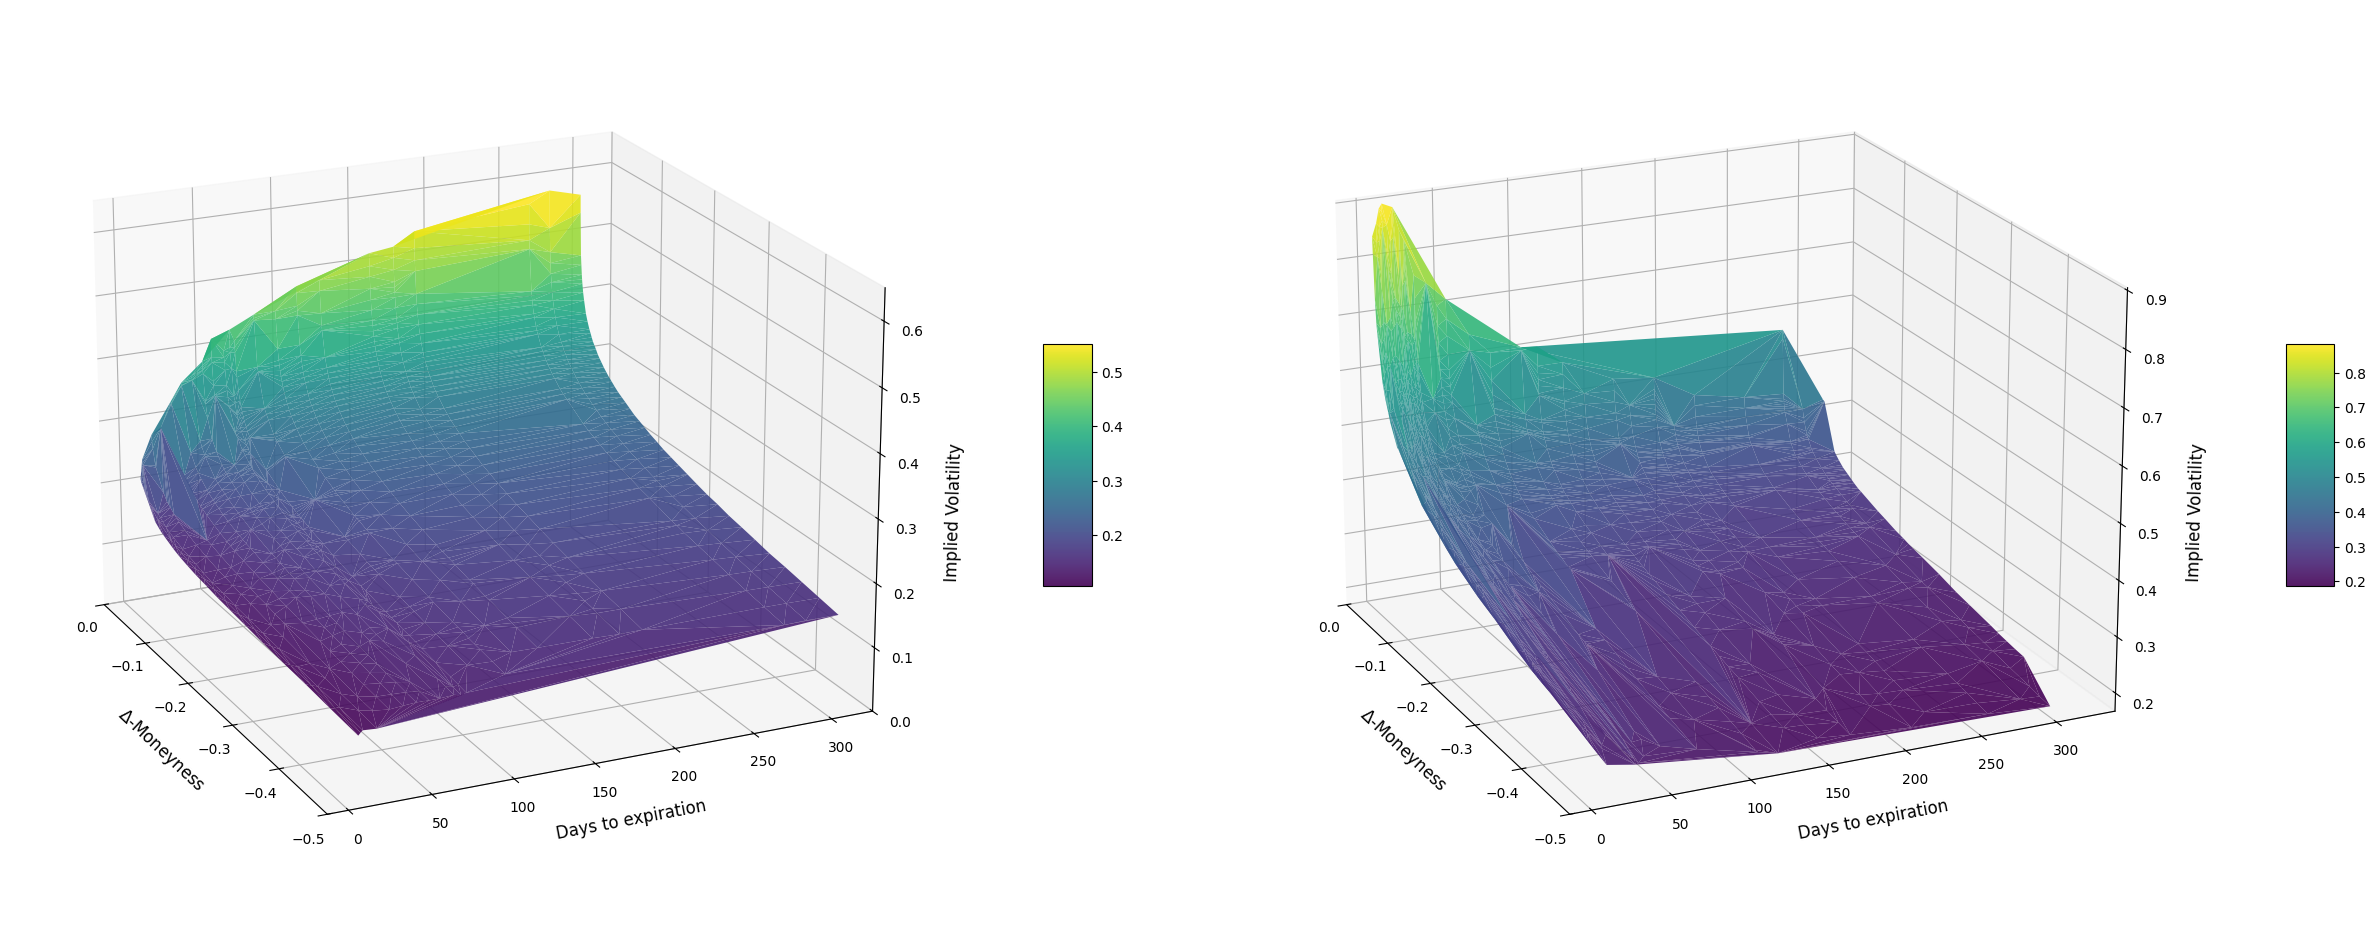

In [5]:
#%matplotlib notebook
#%matplotlib inline

# Set up figure environment
fig, axes = plt.subplots(1,2,figsize=(25,10), subplot_kw={'projection':'3d'})
fig.subplots_adjust(wspace=3)

# 2016 plot
surf1 = axes[0].plot_trisurf(deltas_2016, dtes_2016, ivs_2016,
                       cmap='viridis',
                       linewidth=0.1,
                       antialiased=True,
                       alpha=0.9)

# 2020 plot
surf2 = axes[1].plot_trisurf(deltas_2020, dtes_2020, ivs_2020,
                       cmap='viridis',
                       linewidth=0.1,
                       antialiased=True,
                       alpha=0.9)

# Set x-axis limits
axes[0].set_zlim(0, 0.65)

# Set common specifications
for ax in axes.flat:
    ax.set_xlabel(r'$\Delta$-Moneyness', labelpad=10, fontsize=12)
    ax.set_ylabel('Days to expiration', labelpad=10, fontsize=12)
    ax.set_zlabel('Implied Volatility', labelpad=10, fontsize=12)
    ax.set_xlim(0, -0.5)
    #ax.invert_xaxis()
    ax.view_init(elev=20, azim=-25)

# Plot the colorbars
fig.colorbar(surf1, ax=axes[0], shrink=0.25, aspect=5, pad=0.1)
fig.colorbar(surf2, ax=axes[1], shrink=0.25, aspect=5, pad=0.1)

# Plot the results
plt.tight_layout()
#plt.savefig("/Users/euanbronsky/Downloads/Initial.IV.Plot.png", bbox_inches='tight')
plt.show()

# **Principal component analysis**

In [6]:
data = data[data['moneyness_group'] != 'outside_range']
data = data[data['iv_fun'] <= 0.7]

sigma_delta = data['delta_fun'].std()
sigma_t = data['dte'].std()

# Compute distance
data['distance'] = ((data['delta_fun'] - data['delta_star'])**2 / sigma_delta**2 + (data['dte'] - data['t_star'])**2 / sigma_t**2)

# Locate the index of the groups that minimizes that respective groups distance
df_selected = data.loc[data.groupby(['quote_date','moneyness_group', 'maturity_group'])['distance'].idxmin()]

In [262]:
data

,quote_date,underlying_last,expire_date,dte,strike,iv,bid,ask,delta,option_type,...,T,r,iv_fun,delta_fun,moneyness_group,maturity_group,delta_star,t_star,distance,K/S
151,2010-01-04,1132.99,2010-09-30,268.96,1175.0,0.20774,55.21,57.90,0.42388,call,...,0.736877,0.0018,0.209095,0.419666,ATM_call,180-360,0.4375,270.0,0.003838,1.037079
53,2010-01-04,1132.99,2010-03-18,72.96,1145.0,0.18819,30.00,31.30,0.44747,call,...,0.199890,0.0005,0.188865,0.447165,ATM_call,45-90,0.4375,67.5,0.004511,1.010600
25,2010-01-04,1132.99,2010-02-18,45.00,1145.0,0.17064,19.91,21.20,0.42435,call,...,0.123288,0.0005,0.171210,0.425603,ATM_call,7-45,0.4375,26.0,0.043067,1.010600
109,2010-01-04,1132.99,2010-06-17,163.96,1160.0,0.20300,44.40,46.71,0.43305,call,...,0.449205,0.0018,0.203199,0.430910,ATM_call,90-180,0.4375,135.0,0.096721,1.023840
2103334,2010-01-04,1132.99,2010-09-30,268.96,1100.0,0.22364,74.51,78.50,-0.42260,put,...,0.736877,0.0018,0.225036,-0.422022,ATM_put,180-360,-0.4375,270.0,0.002921,0.970882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2102835,2023-12-29,4772.17,2024-05-17,139.96,5090.0,0.11078,47.00,47.80,0.25044,call,...,0.383452,0.0541,0.112335,0.247906,OTM_call,90-180,0.2500,135.0,0.002874,1.066601
5289294,2023-12-29,4772.17,2024-09-30,275.96,4475.0,0.17345,113.40,115.60,-0.25395,put,...,0.756055,0.0479,0.172104,-0.248377,OTM_put,180-360,-0.2500,270.0,0.004106,0.937729
5288615,2023-12-29,4772.17,2024-03-15,76.96,4620.0,0.13965,47.20,47.80,-0.25389,put,...,0.210849,0.0540,0.139354,-0.251608,OTM_put,45-90,-0.2500,67.5,0.010297,0.968113
5288073,2023-12-29,4772.17,2024-01-23,25.00,4695.0,0.11006,20.40,21.70,-0.25089,put,...,0.068493,0.0560,0.111039,-0.250480,OTM_put,7-45,-0.2500,26.0,0.000117,0.983829


- **Obtain the representative contract for each bucket at each time**

In [7]:
# Retrieve the representative contracts
#df_selected = data.loc[data.groupby(['quote_date', 'moneyness_group', 'maturity_group'])['distance'].idxmin()].reset_index(drop=True)

## Remove IV values above 0.7
#df_selected = df_selected[df_selected['iv_fun'] <= 0.7].copy()

# Compute the log implied volatility
df_selected['log_iv'] = np.log(df_selected['iv_fun'])

- **Reshape the data**

In [8]:
# Reshape the table
df_pivot = df_selected.pivot_table(
    index='quote_date',
    columns=['moneyness_group', 'maturity_group'],
    values='log_iv')

# Drop NaNs since PCA cannot have NaNs
df_pivot = df_pivot.dropna()

# Demean the data
X = df_pivot - df_pivot.mean()

- **Apply principal component analysis**

In [9]:
# Apply the PCA function, and project the directions onto the data
pca = PCA()
PCs = pca.fit_transform(X)

# Recover the 3 factors that explain the data the most
PC1 = PCs[:, 0]
PC2 = PCs[:, 1]
PC3 = PCs[:, 2]

# Cumulative variance explained by the principal components
np.cumsum(pca.explained_variance_ratio_)

array([0.94790176, 0.9680012 , 0.98416093, 0.98871704, 0.99157014,
       0.99353936, 0.99462048, 0.99554944, 0.99629884, 0.99694934,
       0.99744617, 0.9978333 , 0.99819963, 0.99850832, 0.99878936,
       0.99900328, 0.99918574, 0.99934024, 0.99948947, 0.99961905,
       0.99973104, 0.99983797, 0.99992786, 1.        ])

- **Define the mean, maturity spread, and moneyness spread**

In [10]:
# Mean series
mean_series = df_pivot.mean(axis=1)

# Maturity spread series, extract maturities 7-45 and 180-360
short_iv = df_pivot.loc[:, df_pivot.columns.get_level_values(1) == '7-45'].mean(axis=1)
long_iv = df_pivot.loc[:, df_pivot.columns.get_level_values(1) == '180-360'].mean(axis=1)

# Compute the maturity spread
ttm_spread = short_iv - long_iv

# Moneyness spread series, extract two opposing DOTM options
low = df_pivot.loc[:,df_pivot.columns.get_level_values(0) == 'DOTM_put'].mean(axis=1)
high = df_pivot.loc[:,df_pivot.columns.get_level_values(0) == 'DOTM_call'].mean(axis=1)

# Compute the moneyness spread
mm_spread = high - low

# Account for negative correlations
if np.corrcoef(PC2, ttm_spread)[0, 1] < 0:
    PC2 = -PC2
if np.corrcoef(PC3, mm_spread)[0, 1] < 0:
    PC3 = -PC3

- **Plot the results**

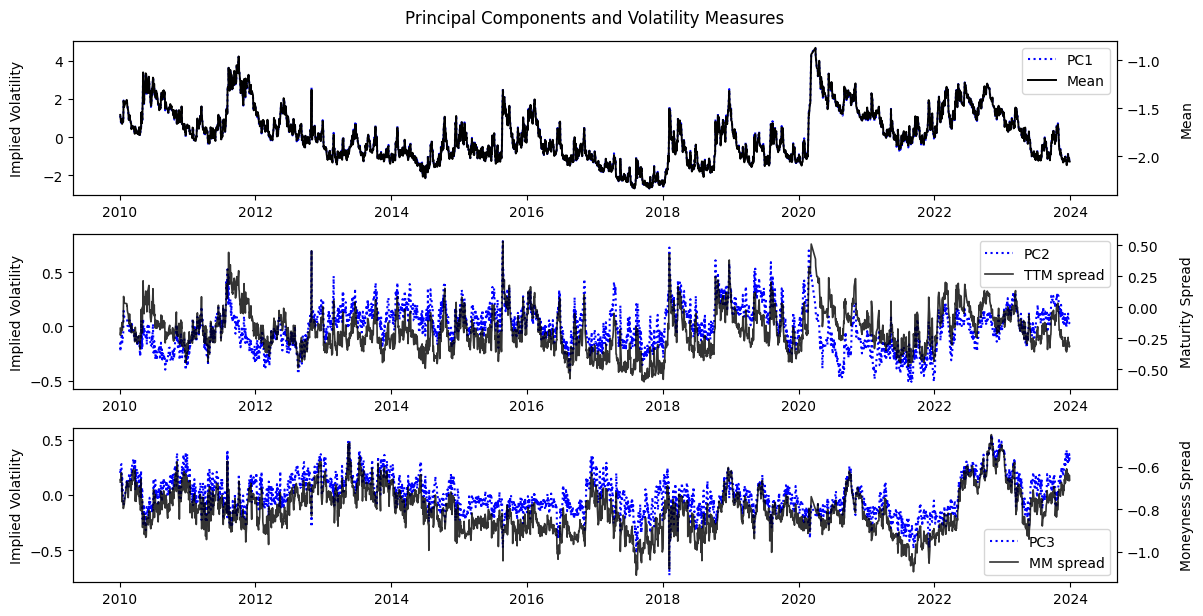

In [40]:
# Create helper function for the legend
def add_legend(ax_left, ax_right, loc='lower left'):
    lines1, labels1 = ax_left.get_legend_handles_labels()
    lines2, labels2 = ax_right.get_legend_handles_labels()
    ax_left.legend(lines1 + lines2, labels1 + labels2, loc=loc)

# Define plotting environment
fig, axes = plt.subplots(3, 1, figsize=(12, 6))

# Plot the mean series
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df_pivot.index, PC1, label = 'PC1', color = 'blue', linestyle = ':')
ax2.plot(df_pivot.index, mean_series, color = 'black', label = 'Mean', alpha=1, linewidth = 1.4)
add_legend(ax1, ax2, loc='upper right')
ax1.set_ylabel('Implied Volatility', fontsize=10)
#ax1.set_title('Factor 1 vs. Average Implied Volatility', fontsize=11)
ax2.set_ylabel('Mean', fontsize=10)

# Plot the time-to-maturity spread
ax3 = axes[1]
ax4 = ax3.twinx()
ax3.plot(df_pivot.index, PC2, label = 'PC2', color='blue', linestyle = ':')
ax4.plot(df_pivot.index, ttm_spread, color='black', label = 'TTM spread', alpha=0.8, linewidth=1.2)
add_legend(ax3, ax4, loc='upper right')
#ax3.set_title('Factor 2 vs. Slope of Volatility Term Structure', fontsize=11)
ax3.set_ylabel('Implied Volatility', fontsize=10)
ax4.set_ylabel('Maturity Spread', fontsize=10)

# Plot the moneyness spread
ax5 = axes[2]
ax6 = ax5.twinx()
ax5.plot(df_pivot.index, PC3, label = 'PC3', color='blue', linestyle = ':')
ax6.plot(df_pivot.index, mm_spread, color = 'black', label = 'MM spread', alpha=0.8, linewidth = 1.2)
add_legend(ax5, ax6, loc='lower right')
#ax5.set_title('Factor 3 vs. Slope of Volatility Smile', fontsize=11)
ax5.set_ylabel('Implied Volatility', fontsize=10)
ax6.set_ylabel('Moneyness Spread', fontsize=10)

#for ax in axes.flat:
    #ax.grid(True, alpha=0.5)

# Plot the results
plt.tight_layout()
fig.suptitle('Principal Components and Volatility Measures', fontsize=12, y=1.02)
fig.align_ylabels(axes)
for ax in [ax2, ax4, ax6]:
    ax.yaxis.set_label_coords(1.06, 0.5)
plt.savefig("/Users/Euan Bronsky/Downloads/pca.plot.png", bbox_inches='tight')
plt.show()